# Waterfilling Levels

In [37]:
import sys
sys.path.insert(1, '../../functions')
import importlib
import numpy as np
import nbformat
import plotly.express
import plotly.express as px
import pandas as pd
import scipy.optimize as optimization
import food_bank_functions
import food_bank_bayesian
import matplotlib.pyplot as plt
import seaborn as sns
from food_bank_functions import *
from food_bank_bayesian import *
import time
importlib.reload(food_bank_functions)

<module 'food_bank_functions' from '../../functions\\food_bank_functions.py'>

### Plotting the distribution

In [38]:
vals = np.loadtxt('../../data/gaussian/vals_15_var_3.csv', delimiter=",")
support = np.loadtxt('../../data/gaussian/support_15_var_3.csv', delimiter=",")
var = variance(support, vals)
med = median(support, vals)
print(med)
print(var)

15.5
9.603062592934334


In [39]:
print(vals)
print(support)
vals[0] = vals[0] + (1 - np.sum(vals))

[0.0000e+00 3.3000e-04 5.3400e-03 4.5740e-02 1.8204e-01 3.3487e-01
 2.8992e-01 1.1717e-01 2.2520e-02 2.0000e-03 7.0000e-05]
[ 2.          4.7         7.4        10.1        12.8        15.5
 18.2        20.9        23.6        26.3        27.20911003]


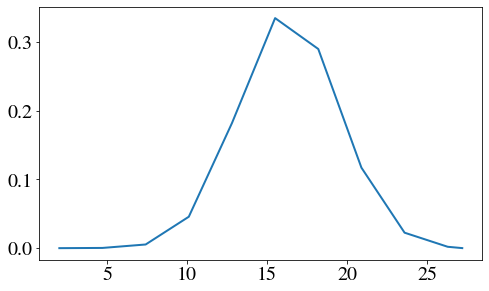

In [40]:
plt.plot(support, vals)

### Test

In [5]:
n = 6
sorted_distribution = support
weights = vals
expected_demand = np.dot(vals, support)
print(expected_demand)
max_budget = n * expected_demand

16.33501163770181


In [6]:
print(max_budget)

98.01006982621087


In [7]:
np.sum(vals)

1.0

In [8]:
group_demands = np.random.choice(size=n, a=sorted_distribution, p=vals)
print(group_demands)

[18.2 18.2 15.5 15.5 15.5 18.2]


In [9]:
print(waterfilling_waste(group_demands, max_budget))

[17.17002328 17.17002328 15.5        15.5        15.5        17.17002328]


In [10]:
print(greedy(group_demands, max_budget))

[18.2        18.2        15.5        15.5        15.5        15.11006983]


In [11]:
print(constant_threshold(group_demands,max_budget,expected_demand))

[16.33501164 16.33501164 15.5        15.5        15.5        16.33501164]


In [12]:
print(waterfilling_proportional_remaining(group_demands, max_budget))

[16.33501164 16.33501164 15.5        15.5        15.5        18.2       ]


In [13]:
print(waterfilling_et_waste([expected_demand for x in range(n)],group_demands,max_budget))

[16.33501164 16.33501164 15.5        15.5        15.5        18.2       ]


In [14]:
print(waterfilling_et_full_waste([expected_demand for x in range(n)],group_demands,max_budget))

[16.33501164 16.33501164 15.5        15.5        15.5        17.17002328]


In [15]:
print(waterfilling_hope_waste_iid(weights, sorted_distribution, group_demands, max_budget))

[18.2        17.49923638 15.5        15.5        15.5        15.81083344]


In [16]:
print(weights)
print(sorted_distribution)

[1.11022302e-16 3.30000000e-04 5.34000000e-03 4.57400000e-02
 1.82040000e-01 3.34870000e-01 2.89920000e-01 1.17170000e-01
 2.25200000e-02 2.00000000e-03 7.00000000e-05]
[ 2.          4.7         7.4        10.1        12.8        15.5
 18.2        20.9        23.6        26.3        27.20911003]


In [17]:
print(waterfilling_hope_full_waste_iid(weights, sorted_distribution, group_demands, max_budget))

[18.2        17.68727402 15.5        15.5        15.5        15.62279581]


In [18]:
print(max_min_heuristic(group_demands, [med for x in range(n)], [expected_demand for x in range(n)], [var for x in range(n)], max_budget))

[17.64375144 17.36103258 14.78549478 14.78549478 14.78549478 18.2       ]


# Experiments

## Varying Number of Groups

### Look at scaling with n

In [19]:
max_n = 100
num_iterations = 100
print(weights)
print(sorted_distribution)

[1.11022302e-16 3.30000000e-04 5.34000000e-03 4.57400000e-02
 1.82040000e-01 3.34870000e-01 2.89920000e-01 1.17170000e-01
 2.25200000e-02 2.00000000e-03 7.00000000e-05]
[ 2.          4.7         7.4        10.1        12.8        15.5
 18.2        20.9        23.6        26.3        27.20911003]


In [20]:
expected_waterfilling_threshold = np.zeros(max_n+1)
num_iterations = 1000
for i in np.arange(2,max_n+1):
    for _ in range(num_iterations):
        budget = i * 15.
        demands = np.random.choice(size=i, a=support, p=vals)
        opt = waterfilling_waste(demands, budget)
        expected_waterfilling_threshold[i] += (1/num_iterations)*max(opt)
print(expected_waterfilling_threshold)

[ 0.          0.         15.4754     15.9453     16.11935    16.29808333
 16.409335   16.37126667 16.4147419  16.42761357 16.48510413 16.46310829
 16.40289196 16.51203619 16.48876494 16.35625474 16.39714437 16.41302798
 16.42084589 16.43019807 16.36359115 16.45468719 16.34967607 16.36493585
 16.39007757 16.28511464 16.30906346 16.33029888 16.30858378 16.27935672
 16.28191997 16.33116591 16.34509531 16.33118171 16.28159316 16.26698491
 16.27486313 16.26309932 16.31314523 16.2511011  16.2565888  16.2388608
 16.25287261 16.24312923 16.22130317 16.23239054 16.289079   16.24784144
 16.24025938 16.22343331 16.23242416 16.23610115 16.23033442 16.23755966
 16.25837709 16.22408269 16.22815625 16.22651799 16.19770349 16.23570469
 16.21657108 16.23766535 16.21076782 16.23264519 16.21496328 16.21508544
 16.2161168  16.20041338 16.23081524 16.21075972 16.182986   16.2258501
 16.20194861 16.1989382  16.19070271 16.21497694 16.20368177 16.22102038
 16.19090852 16.19085381 16.20231358 16.20339288 16.1

In [21]:
data_dict = {'NumGroups':[], 'Norm':[], 'ET-Online':[],'Hope-Online':[], 'Adapt-Threshold':[], 'Threshold':[], 'Expected-Filling':[], 'Greedy':[], 'ET-Full':[], 'Hope-Full':[], 'Max-Min':[]}
num_iterations = 200
for n in np.arange(2,max_n+1,1):
    n = max(int(n),1)
    group_expected_demands = np.zeros(n) + np.dot(weights, sorted_distribution)
    group_median_demands = np.zeros(n) + med
    group_variance = np.zeros(n) + var
    budget = n*expected_demand
    print(n)
    for i in range(num_iterations):
        data_dict['NumGroups'].append(n)

        
        group_demands = np.random.choice(size=n, a=support, p=vals)
        opt = waterfilling_waste(group_demands,budget)
        
        hope_sol = waterfilling_hope_waste_iid(weights, sorted_distribution, group_demands, budget)
        hope_full_sol = waterfilling_hope_full_waste_iid(weights, sorted_distribution, group_demands, budget)
        dynamic = waterfilling_et_waste(group_expected_demands,group_demands,budget)
        et_full = waterfilling_et_full_waste(group_expected_demands, group_demands, budget)
        proportional_threshold = waterfilling_proportional_remaining(group_demands, budget)
        greed_sol = greedy(group_demands,budget)
        threshold = constant_threshold(group_demands,budget,expected_demand)
        expect_threshold = constant_threshold(group_demands, budget, expected_waterfilling_threshold[n])
        max_min_heuristic_sol = max_min_heuristic(group_demands, group_median_demands, group_expected_demands, group_variance, budget)
        
        data_dict['Norm'].append('L1')
        data_dict['Hope-Online'].append(np.sum(np.absolute(opt - hope_sol)))
        data_dict['ET-Online'].append(np.sum(np.absolute(opt-dynamic)))
        data_dict['Adapt-Threshold'].append(np.sum(np.absolute(opt - proportional_threshold)))
        data_dict['Greedy'].append(np.sum(np.absolute(opt-greed_sol)))
        data_dict['Threshold'].append(np.sum(np.absolute(opt-threshold)))
        data_dict['ET-Full'].append(np.sum(np.absolute(opt-et_full)))
        data_dict['Hope-Full'].append(np.sum(np.absolute(opt-hope_full_sol)))
        data_dict['Expected-Filling'].append(np.sum(np.absolute(opt - expect_threshold)))
        data_dict['Max-Min'].append(np.sum(np.absolute(opt - max_min_heuristic_sol)))
        
        data_dict['NumGroups'].append(n)
        data_dict['Norm'].append('Linf')
        data_dict['Hope-Online'].append(np.max(np.absolute(opt - hope_sol)))
        data_dict['ET-Online'].append(np.max(np.absolute(opt-dynamic)))
        data_dict['Adapt-Threshold'].append(np.max(np.absolute(opt - proportional_threshold)))
        data_dict['Greedy'].append(np.max(np.absolute(opt-greed_sol)))
        data_dict['Threshold'].append(np.max(np.absolute(opt-threshold)))
        data_dict['ET-Full'].append(np.max(np.absolute(opt-et_full)))
        data_dict['Hope-Full'].append(np.max(np.absolute(opt-hope_full_sol)))
        data_dict['Expected-Filling'].append(np.max(np.absolute(opt - expect_threshold)))
        data_dict['Max-Min'].append(np.max(np.absolute(opt - max_min_heuristic_sol)))

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [22]:
df = pd.DataFrame(data_dict).melt(id_vars=["NumGroups", 'Norm'])

In [23]:
algos_to_exclude = ['Threshold','Expected-Filling']
data_to_graph = (df[~df.variable.isin(algos_to_exclude)]
                 .rename({'variable': 'Algorithm'}, axis = 1)
                )

In [24]:
plt.style.use('PaperDoubleFig.mplstyle.txt')
# Make some style choices for plotting 
colorWheel =['#2bd1e5',
            '#281bf5',
             '#db1bf5',
             '#F5CD1B',
            '#FF5733','#9cf51b',]
dashesStyles = [[3,1],
            [2,1,10,1],
            [4, 1, 1, 1, 1, 1],[1000,1],[8,2]]

In [25]:
data_to_graph = data_to_graph.sort_values(by='Algorithm')

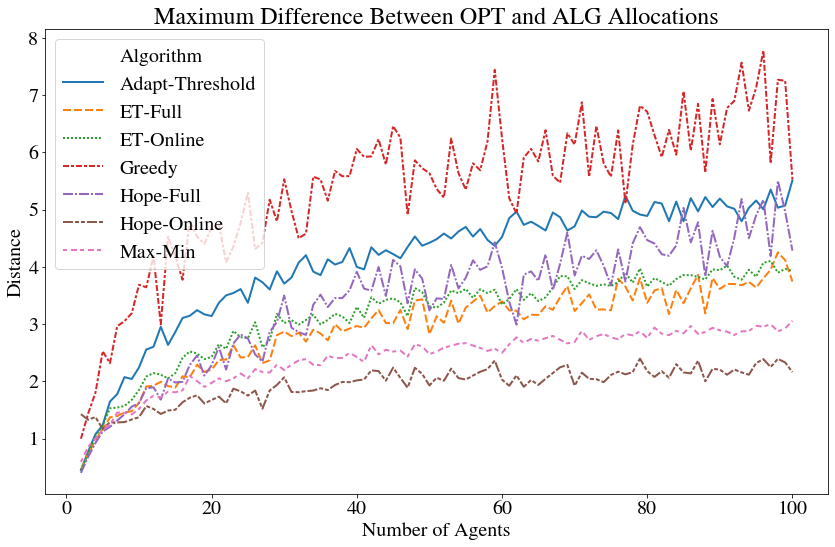

In [26]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(12,8))
plt.title('Gaussian L1')
dash_styles = ["",
               (4, 1.5),
               (1, 1),
               (3, 1, 1.5, 1),
               (5, 1, 1, 1),
               (5, 1, 2, 1, 2, 1),
               (2, 2, 3, 1.5),
               (1, 2.5, 3, 1.2)]

sns.lineplot(x='NumGroups', y='value', hue='Algorithm', style = 'Algorithm', dashes = dash_styles, data=data_to_graph[data_to_graph.Norm == 'Linf'], ci = None)
plt.xlabel('Number of Agents')
plt.ylabel('Distance')
plt.title('Maximum Difference Between OPT and ALG Allocations')
plt.savefig('linf.pdf')

In [27]:
data_to_graph.Algorithm.unique()

array(['Adapt-Threshold', 'ET-Full', 'ET-Online', 'Greedy', 'Hope-Full',
       'Hope-Online', 'Max-Min'], dtype=object)

In [28]:
data_to_graph.head

<bound method NDFrame.head of         NumGroups  Norm        Algorithm      value
79201           2  Linf  Adapt-Threshold   0.000000
92405          35  Linf  Adapt-Threshold   1.806625
92404          35    L1  Adapt-Threshold  15.031420
92403          35  Linf  Adapt-Threshold   4.564988
92402          35    L1  Adapt-Threshold  13.647017
...           ...   ...              ...        ...
330001         35  Linf          Max-Min   2.587805
330002         35    L1          Max-Min  53.449337
330003         35  Linf          Max-Min   2.141662
329996         34    L1          Max-Min  47.808785
356399        100  Linf          Max-Min   3.519769

[277200 rows x 4 columns]>

In [29]:
df.to_csv('scale_with_n.csv')

In [30]:
df.columns

Index(['NumGroups', 'Norm', 'variable', 'value'], dtype='object')

In [31]:
df.head

<bound method NDFrame.head of         NumGroups  Norm   variable       value
0               2    L1  ET-Online    0.000000
1               2  Linf  ET-Online    0.000000
2               2    L1  ET-Online    0.000000
3               2  Linf  ET-Online    0.000000
4               2    L1  ET-Online    0.000000
...           ...   ...        ...         ...
356395        100  Linf    Max-Min    1.029843
356396        100    L1    Max-Min  241.712475
356397        100  Linf    Max-Min    3.239879
356398        100    L1    Max-Min  193.934062
356399        100  Linf    Max-Min    3.519769

[356400 rows x 4 columns]>

In [32]:
df[df.variable == 'Weights'].head

<bound method NDFrame.head of Empty DataFrame
Columns: [NumGroups, Norm, variable, value]
Index: []>

<AxesSubplot:title={'center':'Gaussian L1'}, xlabel='NumGroups', ylabel='value'>

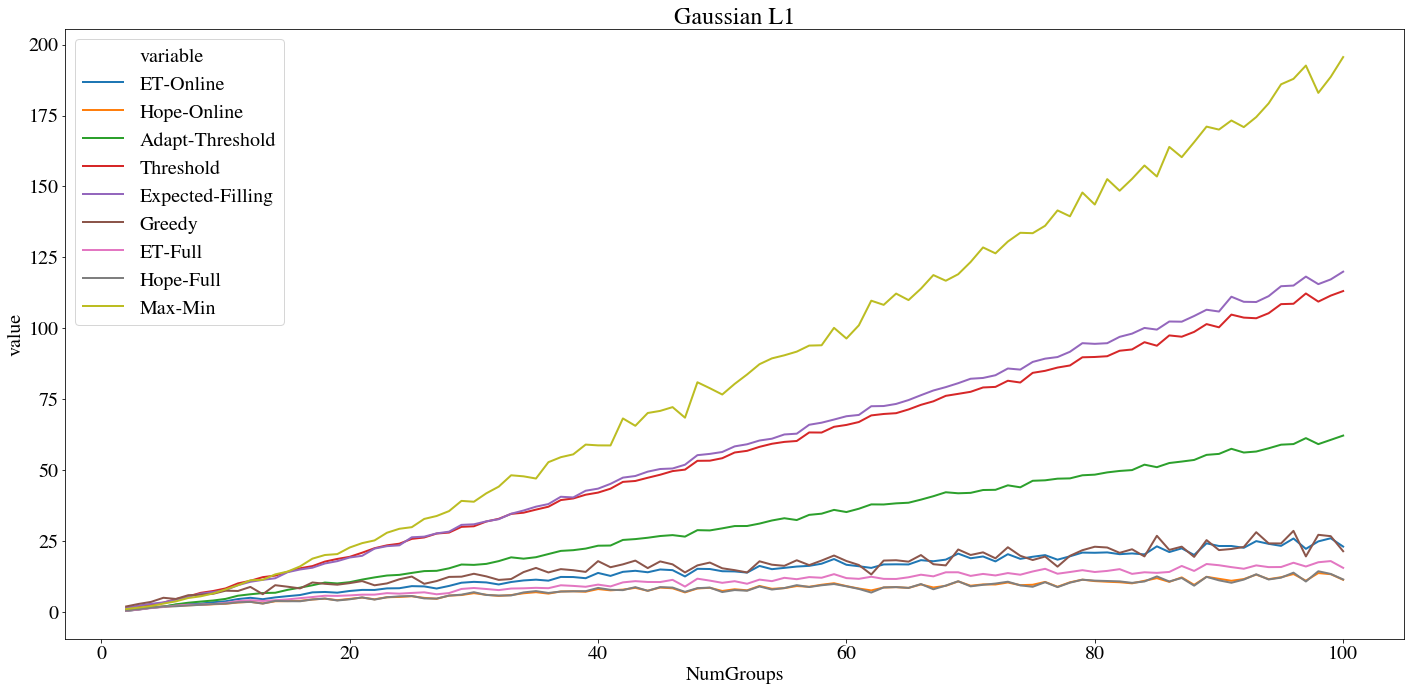

In [33]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
plt.figure(figsize=(20,10))
plt.title('Gaussian L1')
sns.lineplot(x='NumGroups', y='value', hue='variable', data=df[df.Norm == 'L1'], ci = None)

In [ ]:
data_dict = {'Group':[], 'hope_Full':[], 'hope_Online':[],'et_Full':[], 'et_Online':[], 'True':[], 'Max_Min_Heuristic':[]}
num_iterations = 100


for i in range(num_iterations):
    max_n = 100
    
    weights = np.loadtxt('../../data/gaussian/vals_15_var_3.csv', delimiter=",")
    sorted_support = np.loadtxt('../../data/gaussian/support_15_var_3.csv', delimiter=",")
    
    expected_demands = [expected_demand for x in range(max_n)]
    median_demands = [med for _ in range(max_n)]
    variance = [var for _ in range(max_n)]
    
    # print(weights)
    # print(sorted_support)
    # print(expected_demands)
    max_budget = max_n*expected_demand
    
    
    
    group_demands = np.random.choice(size=max_n, a=sorted_support, p=weights).astype(np.float)
    print('Demands for experiment:' + str(group_demands))   
    
    et_full = np.copy(expected_demands)
    et_online = np.sort(np.copy(expected_demands))
    
    et_online_budget = max_budget
    hope_online_budget = max_budget

    hope_online_support = np.copy(sorted_support)
    hope_online_vals = np.copy(weights)*max_n
    
    hope_full_support = np.copy(sorted_support)
    hope_full_vals = np.copy(weights)*max_n
    print('start')
    print(hope_full_vals)
    print(np.sum(hope_full_vals))
    max_min_budget = max_budget
    min_fill = 1
    
    for n in range(max_n):
        # Solve for the various waterfilling levels
        data_dict['Group'].append(n)
        
        # Adds on the true waterfilling level
        data_dict['True'].append(max(waterfilling_sorted(np.sort(np.copy(group_demands)), max_budget)))
        
        
        # et_Full
        
        # Replaces current town's demand with realized demand
        et_full[n] = group_demands[n]
        # Sorts demands
        et_full_sorted = np.sort(np.copy(et_full))
        # Appends maximum allocation based on full demand with full budget
        data_dict['et_Full'].append(max(waterfilling_sorted(et_full_sorted, max_budget)))
            
            
        # et_Online
        
        # Removes expected demand for current agent from list
        et_online = delete_sorted(et_online, expected_demands[n])
        
        # adds in the demand for current location
        new_sorted_list, index = insert_sorted(et_online, group_demands[n])
        tmp_sol = waterfilling_sorted(new_sorted_list, et_online_budget)
        data_dict['et_Online'].append(max(tmp_sol))
        # subtracts off the allocation for the next round
        et_online_budget -= min(tmp_sol[index], et_online_budget, group_demands[n])
        
        
        # hope_Full
        
        # Updating the weights for the observed group
        obs_demand = group_demands[n]
        
        index = np.argmin(np.abs(hope_full_support - obs_demand))
        hope_full_vals -= weights
        hope_full_vals[index] += 1
        
        data_dict['hope_Full'].append(max(waterfilling_sorted_weights(hope_full_support, hope_full_vals, max_budget)))
        
        
#         if n == max_n - 1:
#             print(max(waterfilling_sorted(np.sort(np.copy(group_demands)), max_budget)))
#             print(max(waterfilling_sorted_weights(hope_full_support, hope_full_vals, max_budget)))
#             print(hope_full_vals)
        
        # hope_Online
        obs_demand = group_demands[n]
        
        index = np.argmin(np.abs(hope_online_support - obs_demand))
        hope_online_vals -= weights
        hope_online_vals[index] += 1        
        
        
        tmp_sol = waterfilling_sorted_weights(hope_online_support, hope_online_vals, hope_online_budget)
        hope_online_budget -= min(obs_demand, hope_online_budget, tmp_sol[index])
        
        hope_online_vals[index] -= 1
        data_dict['hope_Online'].append(max(tmp_sol))
        
        # Max_Min
        
        if n == max_n - 1:
            data_dict['Max_Min_Heuristic'].append(min(max_min_budget, group_demands[n]))
        else:
            delta = (median_demands[n] - median_demands[n+1]) / ((1/2)* (median_demands[n] + median_demands[n+1]))
            budget_portion = max_min_budget * (expected_demands[n] + expected_demands[n+1]) / np.sum(expected_demands[n:])
            heuristic_threshold = budget_portion * (group_demands[n] / (group_demands[n] + median_demands[n+1] + delta * np.sqrt(variance[n+1])))
            allocation = min(heuristic_threshold, min_fill*group_demands[n], max_min_budget)
            data_dict['Max_Min_Heuristic'].append(heuristic_threshold)
            
            if allocation / group_demands[n] <= min_fill:
                min_fill = allocation / group_demands[n]
            max_min_budget -= allocation


In [ ]:
np.std(data_dict['True'])

In [ ]:
df = pd.DataFrame(data_dict).melt(id_vars="Group")

In [ ]:
df.to_csv('comparison_of_waterfilling_levels.csv')

In [ ]:
plt.figure(figsize=(20,10))
sns.lineplot(x='Group', y='value', style='variable', hue = 'variable', data=df)
plt.title('Estimated Waterfilling Levels')
plt.xlabel('Estimated Level')

### Calculating Fairness Statistics


In [41]:
num_iterations = 1000
weights = np.loadtxt('../../data/gaussian/vals_15_var_3.csv', delimiter=",")
sorted_distribution = np.loadtxt('../../data/gaussian/support_15_var_3.csv', delimiter=",")
expected_demand = np.dot(weights, sorted_distribution)
n=100

In [42]:
group = np.arange(n)
group_expected_demands = np.zeros(n) + expected_demand
budget = expected_demand*n
score_hope_online = np.zeros((n,num_iterations))
score_hope_full = np.zeros((n,num_iterations))
score_et_online = np.zeros((n,num_iterations))
score_et_full = np.zeros((n,num_iterations))
score_greedy = np.zeros((n,num_iterations))
score_adapt_threshold = np.zeros((n,num_iterations))
score_fixed_threshold = np.zeros((n,num_iterations))
score_expect_threshold = np.zeros((n, num_iterations))
score_max_min = np.zeros((n, num_iterations))

# 8 different algorithms
run_time = np.zeros((6, num_iterations))
env = np.zeros((9,num_iterations))
po = np.zeros((9,num_iterations))
prop = np.zeros((9,num_iterations))
linf = np.zeros((9,num_iterations))
max_min = np.zeros((9, num_iterations))
for i in range(num_iterations):
    budget = n*np.dot(weights, sorted_distribution)

        
    group_demands = np.random.choice(size=n, a=sorted_distribution, p=weights)
    group_median_demands = np.zeros(n) + med
    group_variance = np.zeros(n) + var
    
    
    start = time.perf_counter()
    opt = waterfilling_waste(group_demands,budget)
    run_time[0,i] = time.perf_counter() - start
    
    start = time.perf_counter()
    hope_sol = waterfilling_hope_waste_iid(weights, sorted_distribution, group_demands, budget)
    run_time[1,i] = time.perf_counter() - start
    
    start = time.perf_counter()
    hope_full_sol = waterfilling_hope_full_waste_iid(weights, sorted_distribution, group_demands, budget)
    run_time[2,i] = time.perf_counter() - start
    
    start = time.perf_counter()
    dynamic = waterfilling_et_waste(group_expected_demands,group_demands,budget)
    run_time[3,i] = time.perf_counter() - start
    
    start = time.perf_counter()
    et_full = waterfilling_et_full_waste(group_expected_demands, group_demands, budget)
    run_time[4, i] = time.perf_counter() - start
    
    proportional_threshold = waterfilling_proportional_remaining(group_demands, budget)
    greedy_sol = greedy(group_demands,budget)
    threshold = constant_threshold(group_demands,budget,expected_demand)
    expect_threshold = constant_threshold(group_demands, budget, expected_waterfilling_threshold[n])
    
    start = time.perf_counter()
    max_min_heuristic_sol = max_min_heuristic(group_demands, group_median_demands, group_expected_demands, group_variance, budget)
    run_time[5,i] = time.perf_counter()- start
    # comparing hope_online
    
    score_hope_online[:,i] = opt - hope_sol
    env[0,i] = max(0,np.amax(envy_utility(hope_sol,group_demands)))
    po[0,i] = excess(hope_sol,budget)
    prop[0,i] = np.amax(proportionality_utility(hope_sol,group_demands,budget))
    max_min[0,i] = np.min(utility_ratio(hope_sol, group_demands, budget))
    linf[0,i] = np.amax(np.abs(score_hope_online[:,i]))
    
    
    # comparing hope_full
    
    score_hope_full[:,i] = opt - hope_full_sol
    env[1,i] = max(0,np.amax(envy_utility(hope_full_sol,group_demands)))
    po[1,i] = excess(hope_full_sol,budget)
    prop[1,i] = np.amax(proportionality_utility(hope_full_sol,group_demands,budget))
    max_min[1,i] = np.min(utility_ratio(hope_full_sol, group_demands, budget))
    linf[1,i] = np.amax(np.abs(score_hope_full[:,i]))
    
    
    # comparing et_online
    
    score_et_online[:,i] = opt - dynamic
    env[2,i] = max(0,np.amax(envy_utility(dynamic,group_demands)))
    po[2,i] = excess(dynamic,budget)
    prop[2,i] = np.amax(proportionality_utility(dynamic,group_demands,budget))
    max_min[2,i] = np.min(utility_ratio(dynamic, group_demands, budget))
    linf[2,i] = np.amax(np.abs(score_et_online[:,i]))
    
    
    # comparing et_full
    
    score_et_full[:,i] = opt - et_full
    env[3,i] = max(0,np.amax(envy_utility(et_full,group_demands)))
    po[3,i] = excess(et_full,budget)
    prop[3,i] = np.amax(proportionality_utility(et_full,group_demands,budget))
    max_min[3,i] = np.min(utility_ratio(et_full, group_demands, budget))
    linf[3,i] = np.amax(np.abs(score_et_full[:,i]))
    
    
    # comparing greedy
    
    score_greedy[:,i] = opt - greedy_sol
    env[4,i] = max(0,np.amax(envy_utility(greedy_sol,group_demands)))
    po[4,i] = excess(greedy_sol,budget)
    prop[4,i] = np.amax(proportionality_utility(greedy_sol,group_demands,budget))
    max_min[4,i] = np.min(utility_ratio(greedy_sol, group_demands, budget))
    linf[4,i] = np.amax(np.abs(score_greedy[:,i]))
    
    # comparing fixed_threshold
    
    score_fixed_threshold[:,i] = opt - threshold
    env[5,i] = max(0,np.amax(envy_utility(threshold,group_demands)))
    po[5,i] = excess(threshold,budget)
    prop[5,i] = np.amax(proportionality_utility(threshold,group_demands,budget))
    max_min[5,i] = np.min(utility_ratio(threshold, group_demands, budget))
    linf[5,i] = np.amax(np.abs(score_fixed_threshold[:,i]))
    
    
    # comparing adaptive_threshold
    
    score_adapt_threshold[:,i] = opt - proportional_threshold
    env[6,i] = max(0,np.amax(envy_utility(proportional_threshold,group_demands)))
    po[6,i] = excess(proportional_threshold,budget)
    prop[6,i] = np.amax(proportionality_utility(proportional_threshold,group_demands,budget))
    max_min[6,i] = np.min(utility_ratio(proportional_threshold, group_demands, budget))
    linf[6,i] = np.amax(np.abs(score_adapt_threshold[:,i]))    

    # comparing expected_threshold
    
    score_expect_threshold[:,i] = opt - expect_threshold
    env[7,i] = max(0,np.amax(envy_utility(expect_threshold,group_demands)))
    po[7,i] = excess(expect_threshold,budget)
    prop[7,i] = np.amax(proportionality_utility(expect_threshold,group_demands,budget))
    max_min[7,i] = np.min(utility_ratio(expect_threshold, group_demands, budget))
    linf[7,i] = np.amax(np.abs(score_expect_threshold[:,i]))
    

    # comparing max_min_heurstic
    
    score_max_min[:,i] = opt - max_min_heuristic_sol
    env[8,i] = max(0,np.amax(envy_utility(max_min_heuristic_sol,group_demands)))
    po[8,i] = excess(max_min_heuristic_sol,budget)
    prop[8,i] = np.amax(proportionality_utility(max_min_heuristic_sol,group_demands,budget))
    max_min[8,i] = np.min(utility_ratio(max_min_heuristic_sol, group_demands, budget))
    linf[8,i] = np.amax(np.abs(score_max_min[:,i])) 

In [43]:
score_hope_online = np.average(score_hope_online, axis=1)
score_hope_full = np.average(score_hope_full, axis=1)
score_et_online = np.average(score_et_online, axis=1)
score_et_full = np.average(score_et_full, axis=1)
score_greedy = np.average(score_greedy, axis=1)
score_adapt_threshold = np.average(score_adapt_threshold, axis=1)
score_fixed_threshold = np.average(score_fixed_threshold, axis=1)
score_expect_threshold = np.average(score_expect_threshold, axis=1)
score_max_min = np.average(score_max_min, axis=1)

env = np.average(env,axis=1)
po = np.average(po,axis=1)
prop = np.average(prop,axis=1)
linf = np.average(linf,axis=1)
max_min = np.average(max_min, axis=1)

In [44]:
print(env)

[0.11199666 0.24718263 0.20002533 0.18635814 0.36345821 0.
 0.22027211 0.         0.13399195]


In [45]:
print(po)

[0.1644883  0.15172345 0.24002705 0.25253019 0.13026166 1.27151557
 0.72252563 1.34023901 2.02558045]


In [46]:
print(prop)

[1.11337692e-02 1.95241198e-01 6.25055563e-16 5.26560032e-02
 3.40525916e-01 0.00000000e+00 3.88578059e-18 8.76044130e-03
 1.33991954e-01]


In [48]:
print(max_min)

[0.865102   0.73131062 0.79133268 0.78011317 0.63633647 0.68780986
 0.71849164 0.6810964  0.86600805]


In [49]:
print(linf)

[2.25461872 4.50859696 3.93963224 3.77729545 6.15952475 5.68105772
 5.29163422 5.84049776 2.9583419 ]


In [50]:
print('hope_online, hope_full, et_online, et_full, greedy, fixed_threshold, adaptive_threshold, expected_threshold, max_min')
print('envy:')
print(env)
print('po')
print(po)
print('prop')
print(prop)
print('sum')
print(env+po+prop)
print('max_min')
print(max_min)
print('linf')
print(linf)

hope_online, hope_full, et_online, et_full, greedy, fixed_threshold, adaptive_threshold, expected_threshold, max_min
envy:
[0.11199666 0.24718263 0.20002533 0.18635814 0.36345821 0.
 0.22027211 0.         0.13399195]
po
[0.1644883  0.15172345 0.24002705 0.25253019 0.13026166 1.27151557
 0.72252563 1.34023901 2.02558045]
prop
[1.11337692e-02 1.95241198e-01 6.25055563e-16 5.26560032e-02
 3.40525916e-01 0.00000000e+00 3.88578059e-18 8.76044130e-03
 1.33991954e-01]
sum
[0.28761873 0.59414728 0.44005239 0.49154433 0.83424579 1.27151557
 0.94279774 1.34899945 2.29356436]
max_min
[0.865102   0.73131062 0.79133268 0.78011317 0.63633647 0.68780986
 0.71849164 0.6810964  0.86600805]
linf
[2.25461872 4.50859696 3.93963224 3.77729545 6.15952475 5.68105772
 5.29163422 5.84049776 2.9583419 ]


In [51]:
print(np.average(run_time, axis=1))

[0.0001567  0.00326255 0.00292698 0.00635075 0.01129714 0.00100559]


In [ ]:
data_dict = {'Agent':group, 'Hope-Full': score_hope_online, 'Hope-Online':score_hope_full, 'ET-Online':score_et_online, 'ET-Full':score_et_full, 'Greedy':score_greedy, 'Adapt-Threshold': score_adapt_threshold, 'Fixed-Threshold': score_fixed_threshold, 'Expect-Threshold':score_expect_threshold, 'Max-Min':score_max_min}
df_uniform = pd.DataFrame(data_dict).melt(id_vars="Agent")

In [ ]:
df_uniform.columns

In [ ]:
df_uniform.to_csv('fairness_group_by_group.csv')

In [ ]:
plt.style.use('PaperDoubleFig.mplstyle.txt')
# Make some style choices for plotting 
colorWheel =['#2bd1e5',
            '#281bf5',
             '#db1bf5',
             '#F5CD1B',
            '#FF5733','#9cf51b',]
dashesStyles = [[3,1],
            [2,1,10,1],
            [4, 1, 1, 1, 1, 1],[1000,1],[8,2]]

In [ ]:
algos_to_exclude = ['Fixed-Threshold', 'Expect-Threshold']

In [ ]:
data_to_graph = (df_uniform[~df_uniform.variable.isin(algos_to_exclude)]
                 .rename({'variable': 'Algorithm'}, axis = 1)
                )

In [ ]:
data_to_graph.head

In [ ]:
data_to_graph = data_to_graph.sort_values(by='Algorithm')

In [ ]:
filled_markers = ('o', 'v', '^', '<', '>', '8', 's', 'p', '*', 'h', 'H', 'D', 'd', 'P', 'X')
dash_styles = ["",
               (4, 1.5),
               (1, 1),
               (3, 1, 1.5, 1),
               (5, 1, 1, 1),
               (5, 1, 2, 1, 2, 1),
               (2, 2, 3, 1.5),
               (1, 2.5, 3, 1.2)]


plt.figure(figsize=(12,8))
line = ['-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashdot']
plt.title('Maximum Difference Between OPT and ALG Allocations')

sns.lineplot(x='Agent', y='value', hue='Algorithm', data=data_to_graph, style = 'Algorithm', dashes = dash_styles, ci = None)
plt.title('Allocation Difference per Agent between OPT and ALG')
plt.ylabel('Difference')
plt.xlabel('Agent')
plt.savefig('allocation.pdf')